In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import datetime
import re

Timestamps: [0.0, 89.0, 150.0, 241.0, 299.0, 306.0, 379.0, 379.0, 386.0, 399.0, 403.0, 404.0, 404.0, 455.0, 469.0, 473.0, 486.0, 514.0, 526.0, 621.0, 637.0, 649.0, 745.0, 755.0, 770.0, 835.0, 850.0, 879.0, 931.0, 950.0, 962.0, 1104.0, 1116.0, 1126.0, 1150.0, 1168.0, 1253.0, 1267.0, 1280.0, 1364.0, 1378.0, 1461.0, 1471.0, 1484.0, 1551.0, 1560.0, 1654.0, 1669.0, 1740.0, 1745.0, 1755.0, 1795.0, 1880.0, 1946.0, 1958.0, 1968.0, 1981.0, 2067.0, 2084.0, 2092.0, 2158.0, 2169.0, 2316.0, 2342.0, 2360.0, 2422.0, 2446.0, 2447.0, 2505.0, 2515.0, 2592.0, 2598.0, 2609.0, 2696.0, 2707.0, 2723.0, 2781.0, 2794.0, 2849.0, 2869.0, 2996.0, 3006.0, 3018.0, 3036.0, 3065.0, 3140.0, 3245.0, 3257.0, 3354.0, 3420.0, 3435.0, 3447.0, 3450.0, 3497.0, 3497.0, 3497.0, 3592.0, 3605.0, 3615.0, 3671.0, 3681.0, 3770.0, 3840.0, 3852.0, 3865.0, 3896.0, 4014.9999999999995, 4016.0, 4067.9999999999995, 4091.0, 4152.0, 4165.0, 4181.0, 4277.0, 4290.0, 9810.0, 9873.0, 9932.0, 10034.0, 10083.0, 10140.0, 10192.0, 10281.0, 10375.0,

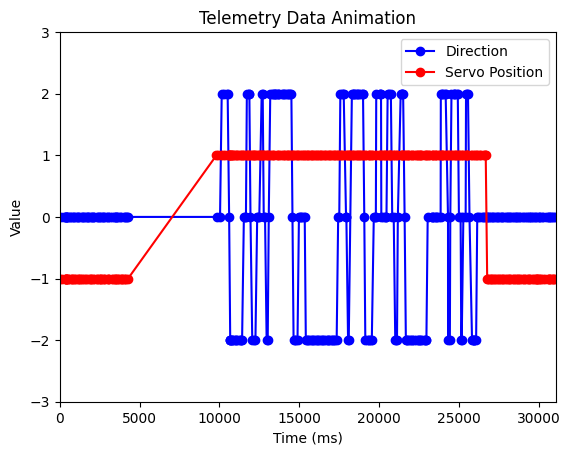

In [7]:
# Function to parse telemetry data
def parse_telemetry(file_path):  # Fixed parameter name):
    timestamps = []
    directions = []
    servo_positions = []
    line_counter = 0
    
    with open(file_path, 'r') as file:  # Ensure file_path is passed correctly
        for line in file:
            if line_counter < 10:
                line_counter += 1
            else:
                line_counter = 0
                match = re.match(r"(\d{2}:\d{2}:\d{2}:\d{3}) -> (Direction|Servo_pos):(-?\d+)", line)
                if match:
                    time_str, key, value = match.groups()
                    time_obj = datetime.datetime.strptime(time_str, "%H:%M:%S:%f")
                    timestamps.append(time_obj)
                    if key == "Direction":
                        directions.append(int(value))
                        servo_positions.append(None)  # Fill with None to keep indexes aligned
                    else:
                        servo_positions.append(int(value))
                        directions.append(None)
    
    return timestamps, directions, servo_positions

# Load data
file_path = "../logs/COM5_2025_03_27.12.22.47.994.txt"  # Replace with your actual file path
timestamps, directions, servo_positions = parse_telemetry(file_path)

# Convert timestamps to relative time (milliseconds)
start_time = timestamps[0]
time_values = [((t - start_time).total_seconds() * 1000) for t in timestamps]

# Filter out None values
direction_times = [time_values[i] for i in range(len(directions)) if directions[i] is not None]
direction_values = [d for d in directions if d is not None]

servo_times = [time_values[i] for i in range(len(servo_positions)) if servo_positions[i] is not None]
servo_values = [s for s in servo_positions if s is not None]

# Initialize figure
fig, ax = plt.subplots()
ax.set_xlim(min(time_values), max(time_values))
ax.set_ylim(
    min(min(direction_values), min(servo_values)) - 1, 
    max(max(direction_values), max(servo_values)) + 1
    )
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Value")
ax.set_title("Telemetry Data Animation")

direction_line, = ax.plot([], [], 'bo-', label="Direction")
servo_line, = ax.plot([], [], 'ro-', label="Servo Position")
ax.legend()

# Animation function
def update(frame):
    direction_line.set_data(direction_times[:frame], direction_values[:frame])
    servo_line.set_data(servo_times[:frame], servo_values[:frame])
    return (direction_line, servo_line)

# Create animation
ani = animation.FuncAnimation(fig=fig, func=update, frames=len(time_values), interval=50, blit=True)

print("Timestamps:", time_values)
print("Directions:", directions)
print("Servo Positions:", servo_positions)

ani.save(filename="telemetry_animation.html", writer="html")
plt.show()
